<a href="https://colab.research.google.com/github/TaniaRivasV/Actividad1/blob/main/Actividad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from google.colab import files
uploaded = files.upload()

Saving datos.csv to datos (2).csv


In [38]:
import pandas as pd

df = pd.read_csv("datos.csv")
df.head()

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
0,ALBACETE,ABENGIBRE,ABENGIBRE,2250,"AVENIDA CASTILLA LA MANCHA, 26","1,529","1,419",P,A,Nº 10.935
1,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 5",NaN,"1,560",R,A,CEPSA
2,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 1","1,409","1,399",P,D,PLENOIL
3,ALBACETE,ALBACETE,ALBACETE,2001,"AVENIDA 1º DE MAYO, S/N","1,539","1,489",P,A,CARREFOUR
4,ALBACETE,ALBACETE,ALBACETE,2001,CALLE PRINCIPE DE ASTURIAS (POLÍGONO DE ROMICA...,"1,549","1,549",P,A,BP ROMICA


In [39]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 11865 entries, 0 to 11864
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Provincia              11865 non-null  str  
 1   Municipio              11865 non-null  str  
 2   Localidad              11865 non-null  str  
 3   Código postal          11865 non-null  int64
 4   Dirección              11865 non-null  str  
 5   Precio gasolina 95 E5  10702 non-null  str  
 6   Precio gasóleo A       11498 non-null  str  
 7   Tipo venta             11865 non-null  str  
 8   Tipo servicio          10803 non-null  str  
 9   Rótulo                 11865 non-null  str  
dtypes: int64(1), str(9)
memory usage: 1.8 MB


Provincia                   0
Municipio                   0
Localidad                   0
Código postal               0
Dirección                   0
Precio gasolina 95 E5    1163
Precio gasóleo A          367
Tipo venta                  0
Tipo servicio            1062
Rótulo                      0
dtype: int64

In [40]:
df["Provincia"].unique()

<ArrowStringArray>
[              'ALBACETE',               'ALICANTE',                'ALMERÍA',
            'ARABA/ÁLAVA',               'ASTURIAS',                  'ÁVILA',
                'BADAJOZ',        'BALEARS (ILLES)',              'BARCELONA',
                'BIZKAIA',                 'BURGOS',                'CÁCERES',
                  'CÁDIZ',              'CANTABRIA',   'CASTELLÓN / CASTELLÓ',
                  'CEUTA',            'CIUDAD REAL',                'CÓRDOBA',
             'CORUÑA (A)',                 'CUENCA',               'GIPUZKOA',
                 'GIRONA',                'GRANADA',            'GUADALAJARA',
                 'HUELVA',                 'HUESCA',                   'JAÉN',
                   'LEÓN',                 'LLEIDA',                   'LUGO',
                 'MADRID',                 'MÁLAGA',                'MELILLA',
                 'MURCIA',                'NAVARRA',                'OURENSE',
               'PALENCIA',       

In [41]:
df_prov = df[df["Provincia"] == "ALICANTE"]
df_prov.head()

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
172,ALICANTE,AGOST,AGOST,3698,AUTOPISTA AP 7 KM. 696,"1,624","1,554",P,D,GALP
173,ALICANTE,AGOST,AGOST,3698,CARRETERA AGOST-NOVELDA KM 2 KM. 2,"1,579","1,529",P,A,CEPSA
174,ALICANTE,AGOST,AGOST,3698,AUTOPISTA AP 7 KM. 696,"1,624","1,554",P,D,GALP
175,ALICANTE,AGOST,AGOST,3698,CARRETERA SAN VICENTE - AGOST KM. 11,"1,599","1,539",P,P,PETRONOR
176,ALICANTE,ALBATERA,ALBATERA,3340,"CARRETERA N-340 KM. 702,1","1,529","1,499",P,A,FTH


In [42]:
df_interes = df_prov[["Municipio", "Precio gasolina 95 E5"]]
df_interes.head()

,Municipio,Precio gasolina 95 E5
172,AGOST,"1,624"
173,AGOST,"1,579"
174,AGOST,"1,624"
175,AGOST,"1,599"
176,ALBATERA,"1,529"


In [43]:
df_interes["Precio gasolina 95 E5"].dtype

<StringDtype(na_value=nan)>

In [44]:
df_interes["Precio gasolina 95 E5"] = pd.to_numeric(
    df_interes["Precio gasolina 95 E5"],
    errors="coerce"
)

In [45]:
df_interes = df_interes.dropna(subset=["Precio gasolina 95 E5"])

In [46]:
print(df_prov["Precio gasolina 95 E5"].head())
print("Cantidad de datos:", len(df_prov))

172    1,624
173    1,579
174    1,624
175    1,599
176    1,529
Name: Precio gasolina 95 E5, dtype: str
Cantidad de datos: 476


In [47]:
df_prov["Precio gasolina 95 E5"] = df_prov["Precio gasolina 95 E5"].astype(str)

In [48]:
df_prov["Precio gasolina 95 E5"] = df_prov["Precio gasolina 95 E5"].str.replace(",", ".", regex=False)

In [49]:
df_prov["Precio gasolina 95 E5"] = pd.to_numeric(
    df_prov["Precio gasolina 95 E5"],
    errors="coerce"
)

In [50]:
df_prov["Precio gasolina 95 E5"].dtype

dtype('float64')

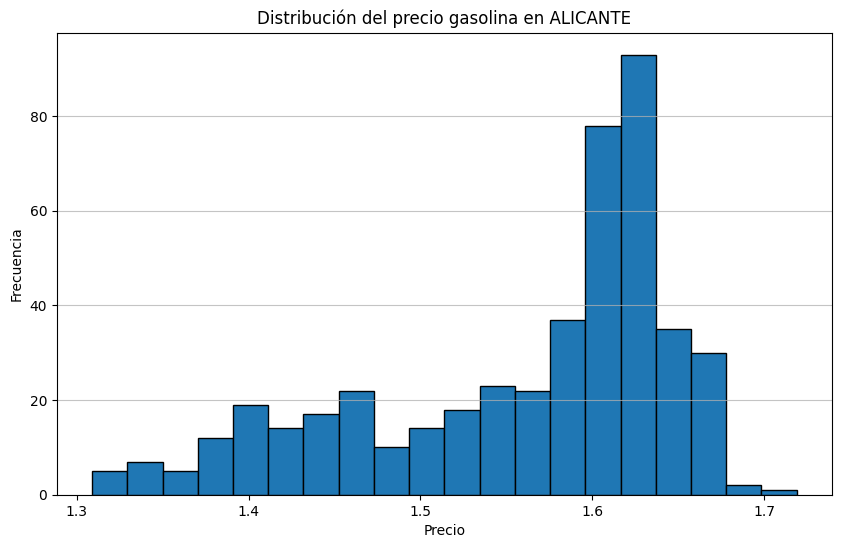

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_prov["Precio gasolina 95 E5"].dropna(), bins=20, edgecolor='black')
plt.title("Distribución del precio gasolina en ALICANTE")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [52]:
print("Información de la columna 'Precio gasolina 95 E5' en df_prov:")
print(df_prov["Precio gasolina 95 E5"].describe())
print("Número de valores NaN en 'Precio gasolina 95 E5':", df_prov["Precio gasolina 95 E5"].isnull().sum())
print("Primeros 5 valores de 'Precio gasolina 95 E5' (después de dropna()):")
display(df_prov["Precio gasolina 95 E5"].dropna().head())

Información de la columna 'Precio gasolina 95 E5' en df_prov:
count    464.000000
mean       1.559170
std        0.089869
min        1.309000
25%        1.499000
50%        1.599000
75%        1.624750
max        1.719000
Name: Precio gasolina 95 E5, dtype: float64
Número de valores NaN en 'Precio gasolina 95 E5': 12
Primeros 5 valores de 'Precio gasolina 95 E5' (después de dropna()):


172    1.624
173    1.579
174    1.624
175    1.599
176    1.529
Name: Precio gasolina 95 E5, dtype: float64

In [53]:

df_prov = df[df["Provincia"] == "ALICANTE"].copy()


df_prov["Precio gasolina 95 E5"] = df_prov["Precio gasolina 95 E5"].astype(str)
df_prov["Precio gasolina 95 E5"] = df_prov["Precio gasolina 95 E5"].str.replace(",", ".", regex=False)
df_prov["Precio gasolina 95 E5"] = pd.to_numeric(
    df_prov["Precio gasolina 95 E5"],
    errors="coerce"
)


df_prov["Precio gasóleo A"] = df_prov["Precio gasóleo A"].astype(str)
df_prov["Precio gasóleo A"] = df_prov["Precio gasóleo A"].str.replace(",", ".", regex=False)
df_prov["Precio gasóleo A"] = pd.to_numeric(
    df_prov["Precio gasóleo A"],
    errors="coerce"
)

print("df_prov head (después de la limpieza):")
display(df_prov.head())
print("df_prov info (después de la limpieza):")
df_prov.info()
print("Información de la columna 'Precio gasolina 95 E5' (después de la limpieza):")
print(df_prov["Precio gasolina 95 E5"].describe())

df_prov head (después de la limpieza):


,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
172,ALICANTE,AGOST,AGOST,3698,AUTOPISTA AP 7 KM. 696,1.624,1.554,P,D,GALP
173,ALICANTE,AGOST,AGOST,3698,CARRETERA AGOST-NOVELDA KM 2 KM. 2,1.579,1.529,P,A,CEPSA
174,ALICANTE,AGOST,AGOST,3698,AUTOPISTA AP 7 KM. 696,1.624,1.554,P,D,GALP
175,ALICANTE,AGOST,AGOST,3698,CARRETERA SAN VICENTE - AGOST KM. 11,1.599,1.539,P,P,PETRONOR
176,ALICANTE,ALBATERA,ALBATERA,3340,"CARRETERA N-340 KM. 702,1",1.529,1.499,P,A,FTH


df_prov info (después de la limpieza):
<class 'pandas.DataFrame'>
RangeIndex: 476 entries, 172 to 647
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Provincia              476 non-null    str    
 1   Municipio              476 non-null    str    
 2   Localidad              476 non-null    str    
 3   Código postal          476 non-null    int64  
 4   Dirección              476 non-null    str    
 5   Precio gasolina 95 E5  464 non-null    float64
 6   Precio gasóleo A       470 non-null    float64
 7   Tipo venta             476 non-null    str    
 8   Tipo servicio          435 non-null    str    
 9   Rótulo                 476 non-null    str    
dtypes: float64(2), int64(1), str(7)
memory usage: 69.2 KB
Información de la columna 'Precio gasolina 95 E5' (después de la limpieza):
count    464.000000
mean       1.559170
std        0.089869
min        1.309000
25%        1.499000
50%   

In [54]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


df_interes = df_prov[["Municipio", "Precio gasolina 95 E5"]].copy()


df_interes = df_interes.dropna(subset=["Precio gasolina 95 E5"])

scaler = MinMaxScaler()
df_interes["Precio_normalizado"] = scaler.fit_transform(
    df_interes[["Precio gasolina 95 E5"]]
)

df_interes.head()

,Municipio,Precio gasolina 95 E5,Precio_normalizado
172,AGOST,1.624,0.768293
173,AGOST,1.579,0.658537
174,AGOST,1.624,0.768293
175,AGOST,1.599,0.707317
176,ALBATERA,1.529,0.536585


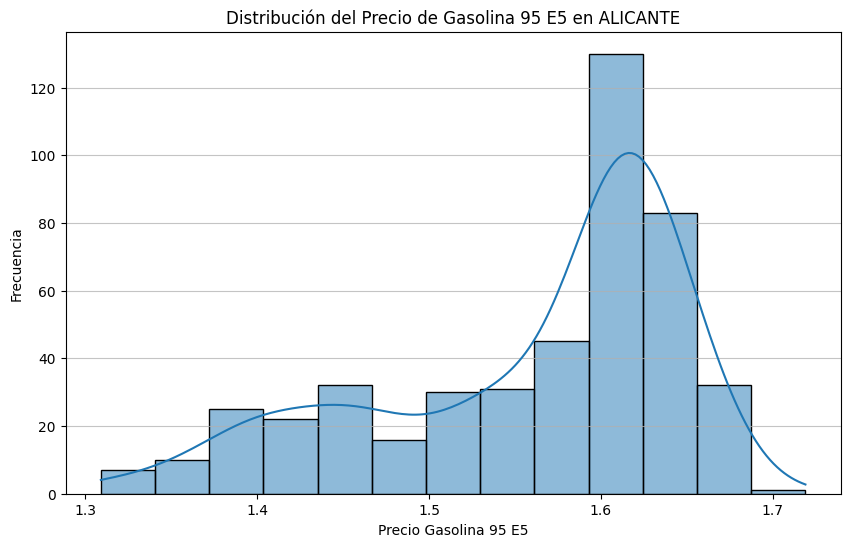

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df_prov["Precio gasolina 95 E5"].dropna(), kde=True)
plt.title("Distribución del Precio de Gasolina 95 E5 en ALICANTE")
plt.xlabel("Precio Gasolina 95 E5")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [56]:
try:
    print(df_prov.head())
    print(f"df_prov es de tipo: {type(df_prov)}")
except NameError:
    print("Error: df_prov no está definida.")

    Provincia Municipio Localidad  Código postal  \
172  ALICANTE     AGOST     AGOST           3698   
173  ALICANTE     AGOST     AGOST           3698   
174  ALICANTE     AGOST     AGOST           3698   
175  ALICANTE     AGOST     AGOST           3698   
176  ALICANTE  ALBATERA  ALBATERA           3340   

                                Dirección  Precio gasolina 95 E5  \
172                AUTOPISTA AP 7 KM. 696                  1.624   
173    CARRETERA AGOST-NOVELDA KM 2 KM. 2                  1.579   
174                AUTOPISTA AP 7 KM. 696                  1.624   
175  CARRETERA SAN VICENTE - AGOST KM. 11                  1.599   
176             CARRETERA N-340 KM. 702,1                  1.529   

     Precio gasóleo A Tipo venta Tipo servicio    Rótulo  
172             1.554          P             D      GALP  
173             1.529          P             A     CEPSA  
174             1.554          P             D      GALP  
175             1.539          P          

In [57]:

df_cleaned = df.copy()
df_cleaned["Precio gasolina 95 E5"] = df_cleaned["Precio gasolina 95 E5"].astype(str)
df_cleaned["Precio gasolina 95 E5"] = df_cleaned["Precio gasolina 95 E5"].str.replace(",", ".", regex=False)
df_cleaned["Precio gasolina 95 E5"] = pd.to_numeric(
    df_cleaned["Precio gasolina 95 E5"],
    errors="coerce"
)


df_cleaned = df_cleaned.dropna(subset=["Precio gasolina 95 E5"])


precio_por_provincia = df_cleaned.groupby("Provincia")["Precio gasolina 95 E5"].agg([
    "min",
    "max"
]).reset_index()


precio_por_provincia.columns = ["Provincia", "Precio más bajo", "Precio más alto"]


print("Precios más altos y más bajos de gasolina 95 E5 por provincia:")
display(precio_por_provincia.sort_values(by="Precio más bajo"))

Precios más altos y más bajos de gasolina 95 E5 por provincia:


,Provincia,Precio más bajo,Precio más alto
36,PALMAS (LAS),1.037,1.484
40,SANTA CRUZ DE TENERIFE,1.087,1.587
30,MELILLA,1.173,1.174
12,CEUTA,1.244,1.264
22,GUADALAJARA,1.253,1.688
1,ALICANTE,1.309,1.719
31,MURCIA,1.319,1.950
28,LUGO,1.319,1.639
42,SEVILLA,1.319,1.719
3,ARABA/ÁLAVA,1.322,1.669


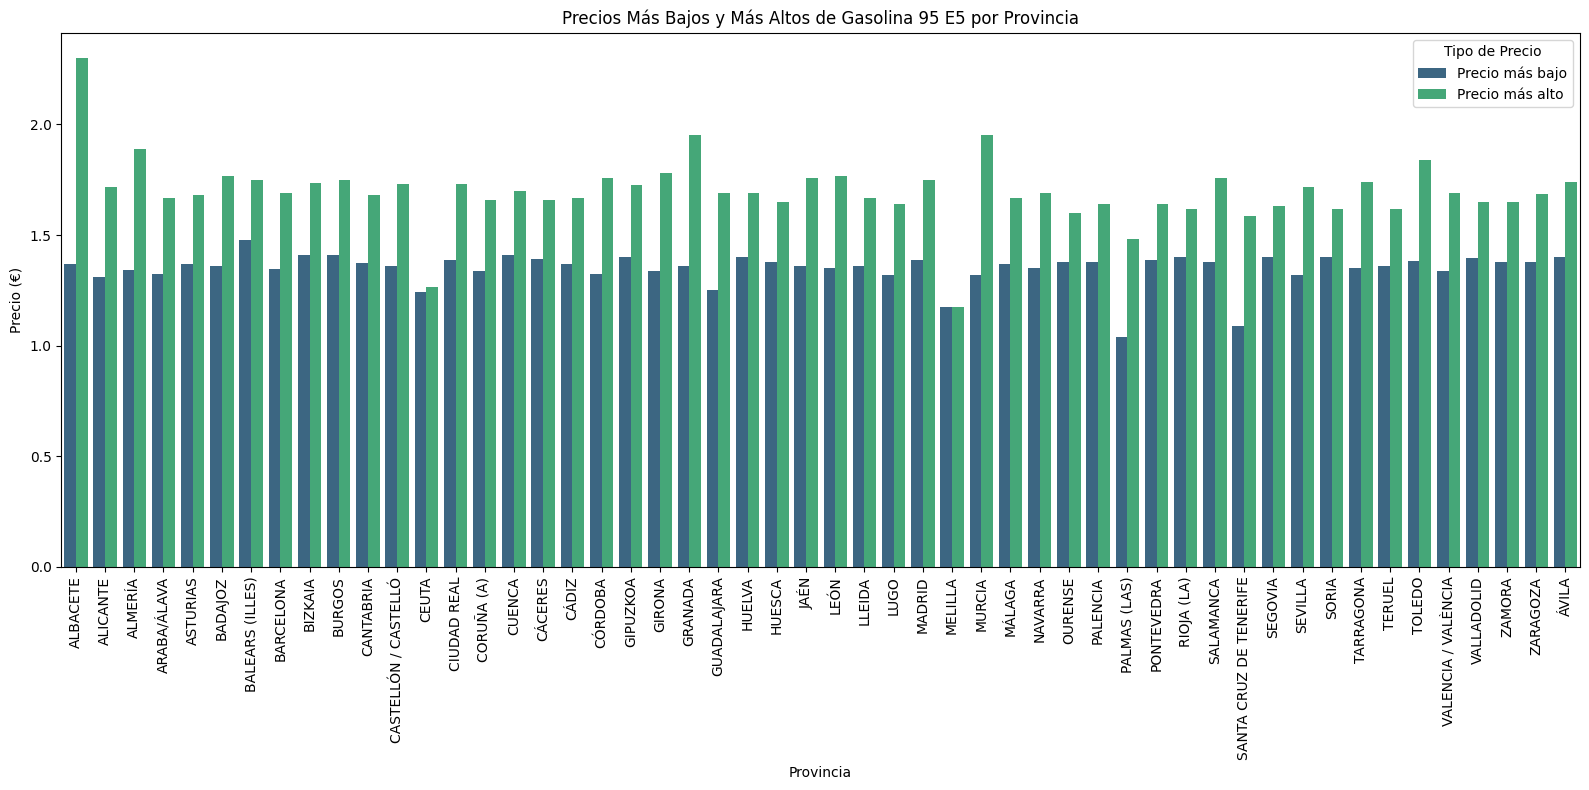

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df_long = precio_por_provincia.melt(id_vars=['Provincia'], var_name='Tipo de Precio', value_name='Precio')

plt.figure(figsize=(16, 8))
sns.barplot(x='Provincia', y='Precio', hue='Tipo de Precio', data=df_long, palette='viridis')
plt.title('Precios Más Bajos y Más Altos de Gasolina 95 E5 por Provincia')
plt.xlabel('Provincia')
plt.ylabel('Precio (€)')
plt.xticks(rotation=90)
plt.legend(title='Tipo de Precio')
plt.tight_layout()
plt.show()

/tmp/ipython-input-9054/2174477175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Municipio', y='Precio gasolina 95 E5', data=gasolina_por_municipio.sort_values(by='Precio gasolina 95 E5', ascending=False), palette='viridis')


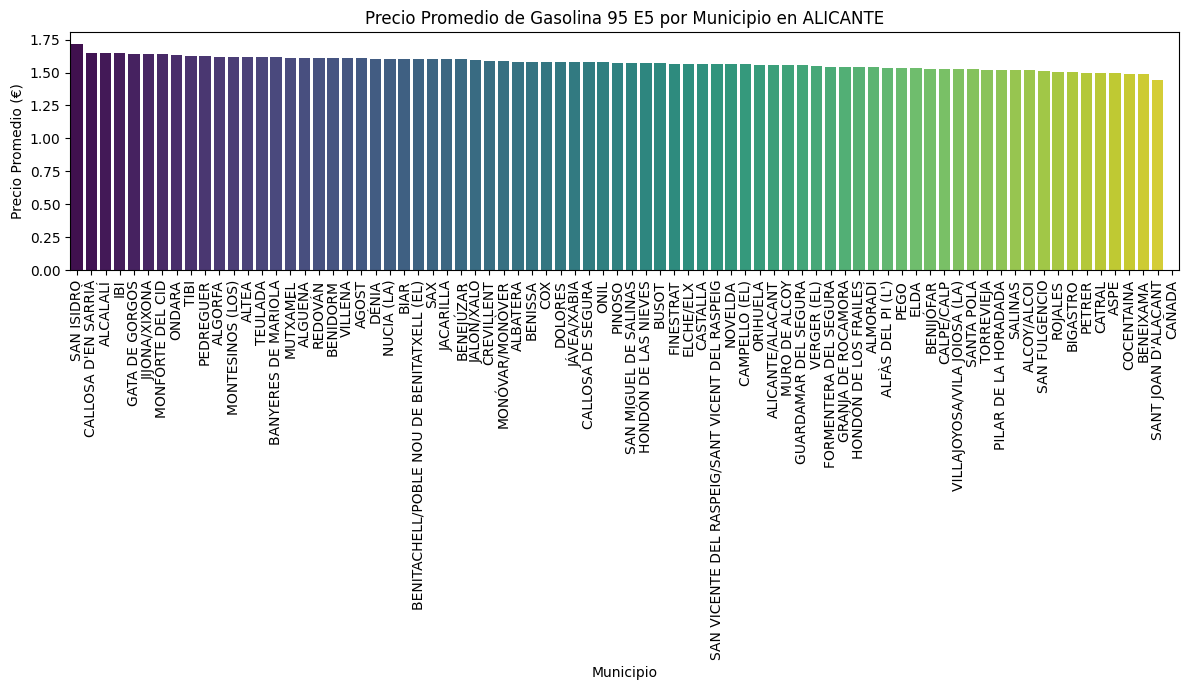

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns


gasolina_por_municipio = df_prov.groupby('Municipio')['Precio gasolina 95 E5'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Municipio', y='Precio gasolina 95 E5', data=gasolina_por_municipio.sort_values(by='Precio gasolina 95 E5', ascending=False), palette='viridis')
plt.title('Precio Promedio de Gasolina 95 E5 por Municipio en ALICANTE')
plt.xlabel('Municipio')
plt.ylabel('Precio Promedio (€)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipython-input-9054/1880872477.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Municipio', y='Precio gasóleo A', data=gasoleo_por_municipio.sort_values(by='Precio gasóleo A', ascending=False), palette='plasma')


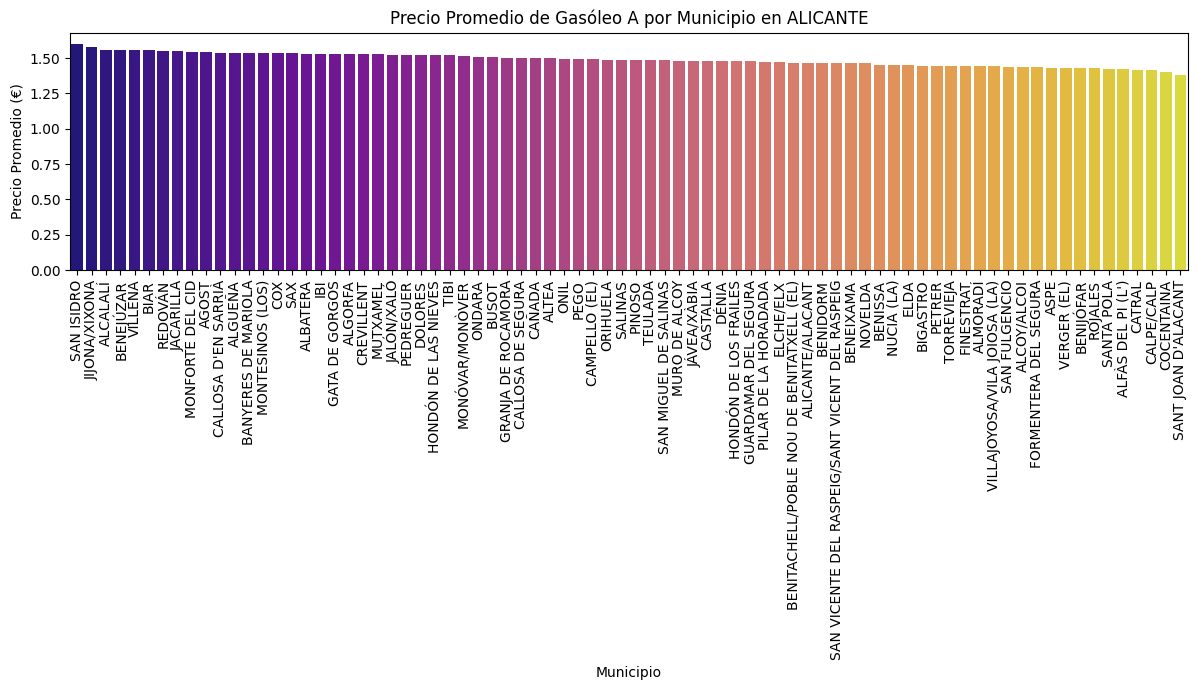

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns


gasoleo_por_municipio = df_prov.groupby('Municipio')['Precio gasóleo A'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Municipio', y='Precio gasóleo A', data=gasoleo_por_municipio.sort_values(by='Precio gasóleo A', ascending=False), palette='plasma')
plt.title('Precio Promedio de Gasóleo A por Municipio en ALICANTE')
plt.xlabel('Municipio')
plt.ylabel('Precio Promedio (€)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipython-input-9054/1082791688.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_rotulos.index, y=top10_rotulos.values, palette='viridis')


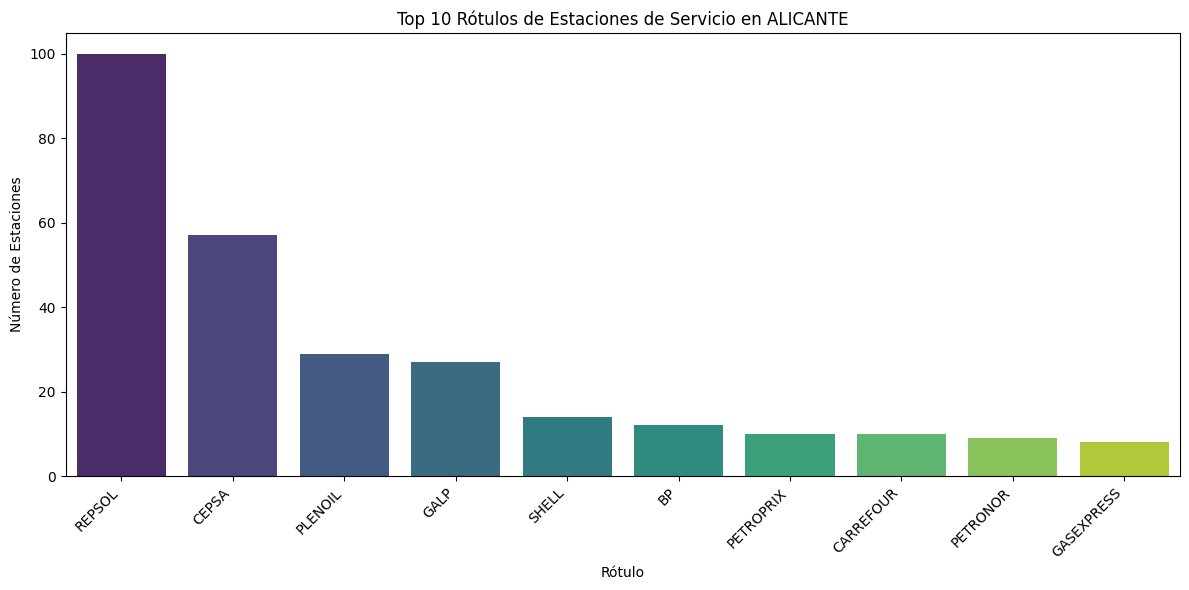

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

conteo_rotulos = df_prov["Rótulo"].value_counts()

top10_rotulos = conteo_rotulos.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10_rotulos.index, y=top10_rotulos.values, palette='viridis')
plt.title("Top 10 Rótulos de Estaciones de Servicio en ALICANTE")
plt.xlabel("Rótulo")
plt.ylabel("Número de Estaciones")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()